## 1. Comprehension et exploration des donnees

## Importer les bibliotiques

In [ ]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Charger les donnees

In [ ]:
df=pd.read_excel("Telecel_revenue.xlsx")

In [ ]:
df

## Lire les 05 premieres lignes

In [ ]:
df.head()

## Definir les types de colonnes

In [ ]:
df.info()

## Voir la description de la dataframe

In [ ]:
df.describe()

In [ ]:
df.sample(10)

## 2. Nettoyage 

## Detection des valeurs manquantes

In [8]:
df.isnull().sum()

DateJ                      0
HEURE                    999
CATEGORIE                  0
NOMBRE                     0
DURATION                   0
AmountPrincipal            0
AmountBonus                0
forfait_TEMPS          40549
forfait_DUREE          40549
forfait_OCTETS         40549
UpFlux                 76349
DownFlux               76349
OCTETS                 86124
VOLUME_DATA_FACTURE        0
dtype: int64

In [9]:
total_missing= df.isnull().sum().sum()
print("\nLe nombre total de valeurs manquantes est de :",total_missing)


Le nombre total de valeurs manquantes est de : 361468


## Suppression des valeurs manquantes

In [10]:
df.dropna(inplace=True)

In [11]:
df

,DateJ,HEURE,CATEGORIE,NOMBRE,DURATION,AmountPrincipal,AmountBonus,forfait_TEMPS,forfait_DUREE,forfait_OCTETS,UpFlux,DownFlux,OCTETS,VOLUME_DATA_FACTURE
86127,2020-01-01,0.0,DATA,4101,0,1.087950e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.575100e+11,0
86128,2020-01-01,0.0,FORFAITS,399734,0,1.130650e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.388608e+08,0
86129,2020-01-01,1.0,FORFAITS,1508,0,2.161350e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.145728e+08,0
86130,2020-01-01,1.0,DATA,1488,0,4.747500e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.272280e+11,0
86131,2020-01-01,2.0,DATA,843,0,2.138750e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.111976e+11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272984,2025-09-12,6.0,VOIX,107227,5720071,8.953485e+05,3.015970e+06,0.0,213726.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0
272985,2025-09-12,7.0,DATA,140417,200096177040,1.589861e+06,0.000000e+00,0.0,0.0,1.949098e+11,2.430032e+10,1.757959e+11,3.867763e+12,122336320573560
272986,2025-09-12,7.0,FORFAITS,2500,4,2.142300e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.095217e+12,0
272987,2025-09-12,7.0,SMS,6942,6942,2.620600e+04,2.078450e+04,3918.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0


In [12]:
total_missing= df.isnull().sum().sum()
print("\nLe nombre total de valeurs manquantes est de :",total_missing)


Le nombre total de valeurs manquantes est de : 0


## Verifier s'il ya des colonnes vides ou pas

In [13]:
print("\nColonnes vides :",df.columns[df.isnull().all()].tolist())


Colonnes vides : []


## Supprimer les colonnes completement vide

In [14]:
df.dropna(axis=1 , how='all', inplace=True)

In [15]:
df

,DateJ,HEURE,CATEGORIE,NOMBRE,DURATION,AmountPrincipal,AmountBonus,forfait_TEMPS,forfait_DUREE,forfait_OCTETS,UpFlux,DownFlux,OCTETS,VOLUME_DATA_FACTURE
86127,2020-01-01,0.0,DATA,4101,0,1.087950e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.575100e+11,0
86128,2020-01-01,0.0,FORFAITS,399734,0,1.130650e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.388608e+08,0
86129,2020-01-01,1.0,FORFAITS,1508,0,2.161350e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.145728e+08,0
86130,2020-01-01,1.0,DATA,1488,0,4.747500e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.272280e+11,0
86131,2020-01-01,2.0,DATA,843,0,2.138750e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.111976e+11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272984,2025-09-12,6.0,VOIX,107227,5720071,8.953485e+05,3.015970e+06,0.0,213726.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0
272985,2025-09-12,7.0,DATA,140417,200096177040,1.589861e+06,0.000000e+00,0.0,0.0,1.949098e+11,2.430032e+10,1.757959e+11,3.867763e+12,122336320573560
272986,2025-09-12,7.0,FORFAITS,2500,4,2.142300e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.095217e+12,0
272987,2025-09-12,7.0,SMS,6942,6942,2.620600e+04,2.078450e+04,3918.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0


## Supprimer les doublons

In [16]:
df=df.drop_duplicates()

In [17]:
df

,DateJ,HEURE,CATEGORIE,NOMBRE,DURATION,AmountPrincipal,AmountBonus,forfait_TEMPS,forfait_DUREE,forfait_OCTETS,UpFlux,DownFlux,OCTETS,VOLUME_DATA_FACTURE
86127,2020-01-01,0.0,DATA,4101,0,1.087950e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.575100e+11,0
86128,2020-01-01,0.0,FORFAITS,399734,0,1.130650e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.388608e+08,0
86129,2020-01-01,1.0,FORFAITS,1508,0,2.161350e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.145728e+08,0
86130,2020-01-01,1.0,DATA,1488,0,4.747500e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.272280e+11,0
86131,2020-01-01,2.0,DATA,843,0,2.138750e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.111976e+11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272984,2025-09-12,6.0,VOIX,107227,5720071,8.953485e+05,3.015970e+06,0.0,213726.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0
272985,2025-09-12,7.0,DATA,140417,200096177040,1.589861e+06,0.000000e+00,0.0,0.0,1.949098e+11,2.430032e+10,1.757959e+11,3.867763e+12,122336320573560
272986,2025-09-12,7.0,FORFAITS,2500,4,2.142300e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.095217e+12,0
272987,2025-09-12,7.0,SMS,6942,6942,2.620600e+04,2.078450e+04,3918.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0


## Verifications des doublons

In [18]:
df.isna().sum()

DateJ                  0
HEURE                  0
CATEGORIE              0
NOMBRE                 0
DURATION               0
AmountPrincipal        0
AmountBonus            0
forfait_TEMPS          0
forfait_DUREE          0
forfait_OCTETS         0
UpFlux                 0
DownFlux               0
OCTETS                 0
VOLUME_DATA_FACTURE    0
dtype: int64

In [19]:
df.duplicated().any()

np.False_

## 3. Correction des incoherences

## Normaliser les colonnes

In [20]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", " _ ")

In [21]:
df

,datej,heure,categorie,nombre,duration,amountprincipal,amountbonus,forfait_temps,forfait_duree,forfait_octets,upflux,downflux,octets,volume_data_facture
86127,2020-01-01,0.0,DATA,4101,0,1.087950e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.575100e+11,0
86128,2020-01-01,0.0,FORFAITS,399734,0,1.130650e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.388608e+08,0
86129,2020-01-01,1.0,FORFAITS,1508,0,2.161350e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.145728e+08,0
86130,2020-01-01,1.0,DATA,1488,0,4.747500e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.272280e+11,0
86131,2020-01-01,2.0,DATA,843,0,2.138750e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.111976e+11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272984,2025-09-12,6.0,VOIX,107227,5720071,8.953485e+05,3.015970e+06,0.0,213726.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0
272985,2025-09-12,7.0,DATA,140417,200096177040,1.589861e+06,0.000000e+00,0.0,0.0,1.949098e+11,2.430032e+10,1.757959e+11,3.867763e+12,122336320573560
272986,2025-09-12,7.0,FORFAITS,2500,4,2.142300e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.095217e+12,0
272987,2025-09-12,7.0,SMS,6942,6942,2.620600e+04,2.078450e+04,3918.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0


## Remplacer les valeurs manquantes NaN par 0

In [22]:
df=df.fillna(0)

In [23]:
df

,datej,heure,categorie,nombre,duration,amountprincipal,amountbonus,forfait_temps,forfait_duree,forfait_octets,upflux,downflux,octets,volume_data_facture
86127,2020-01-01,0.0,DATA,4101,0,1.087950e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.575100e+11,0
86128,2020-01-01,0.0,FORFAITS,399734,0,1.130650e+06,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.388608e+08,0
86129,2020-01-01,1.0,FORFAITS,1508,0,2.161350e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.145728e+08,0
86130,2020-01-01,1.0,DATA,1488,0,4.747500e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.272280e+11,0
86131,2020-01-01,2.0,DATA,843,0,2.138750e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.111976e+11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272984,2025-09-12,6.0,VOIX,107227,5720071,8.953485e+05,3.015970e+06,0.0,213726.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0
272985,2025-09-12,7.0,DATA,140417,200096177040,1.589861e+06,0.000000e+00,0.0,0.0,1.949098e+11,2.430032e+10,1.757959e+11,3.867763e+12,122336320573560
272986,2025-09-12,7.0,FORFAITS,2500,4,2.142300e+05,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.095217e+12,0
272987,2025-09-12,7.0,SMS,6942,6942,2.620600e+04,2.078450e+04,3918.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0


## Verifier la taille de la BDD finale apres nettoyage

In [24]:
print("--- La base de donnee apres nettoyage comprends : ---")
print(df.shape)  

--- La base de donnee apres nettoyage comprends : ---
(159754, 14)


## Copie du DataFrame nettoyé

In [25]:
df_eda = df.copy()

## Analyse Exploratoire des donnees

## Style des graphes

In [26]:
sns.set(style="whitegrid")

## Analyse univariee

In [27]:
print("Apercu des donnees :")
print(df_eda.head)

Apercu des donnees :
<bound method NDFrame.head of             datej  heure categorie  nombre      duration  amountprincipal  \
86127  2020-01-01    0.0      DATA    4101             0     1.087950e+06   
86128  2020-01-01    0.0  FORFAITS  399734             0     1.130650e+06   
86129  2020-01-01    1.0  FORFAITS    1508             0     2.161350e+05   
86130  2020-01-01    1.0      DATA    1488             0     4.747500e+05   
86131  2020-01-01    2.0      DATA     843             0     2.138750e+05   
...           ...    ...       ...     ...           ...              ...   
272984 2025-09-12    6.0      VOIX  107227       5720071     8.953485e+05   
272985 2025-09-12    7.0      DATA  140417  200096177040     1.589861e+06   
272986 2025-09-12    7.0  FORFAITS    2500             4     2.142300e+05   
272987 2025-09-12    7.0       SMS    6942          6942     2.620600e+04   
272988 2025-09-12    7.0      VOIX   76943       4030572     6.124712e+05   

         amountbonus  fo

In [28]:
print("]\Resume Statistique")
print(df_eda.describe(include="all"))

]\Resume Statistique
                                datej          heure categorie        nombre  \
count                          159754  159754.000000    159754  1.597540e+05   
unique                            NaN            NaN         5           NaN   
top                               NaN            NaN      DATA           NaN   
freq                              NaN            NaN     49952           NaN   
mean    2023-04-16 18:13:46.120159744      11.522854       NaN  1.294261e+05   
min               2020-01-01 00:00:00       0.000000       NaN  1.000000e+00   
25%               2022-03-30 00:00:00       6.000000       NaN  3.513000e+03   
50%               2023-06-15 00:00:00      12.000000       NaN  2.531000e+04   
75%               2024-07-30 00:00:00      17.000000       NaN  2.109378e+05   
max               2025-09-12 00:00:00      23.000000       NaN  1.239544e+06   
std                               NaN       6.895742       NaN  1.829477e+05   

            durati

## Distribution du chiffre d'affaires

Ce graphe permettra de verifier la repartition du chiffre d'affaire et detecter les valeurs atypiques qui peuvent influencer les analyses.

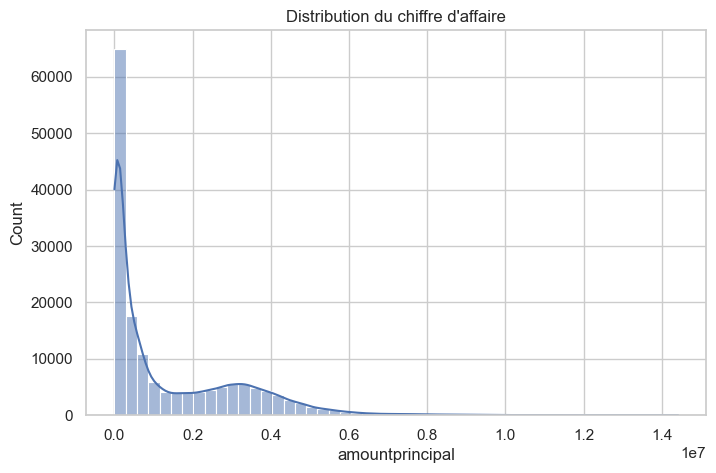

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df_eda['amountprincipal'], bins=50, kde=True)
plt.title("Distribution du chiffre d'affaire")
plt.show()

Remarque : La majorite des transactions se concentrent sur les petits montants, avec une queue longue vers les valeurs elevees.

## Distribution des bonus

Ce graphe permettra de comprendre si les bonus suivent la meme logique que le chiffre d'affaire et mesurer leur poids.

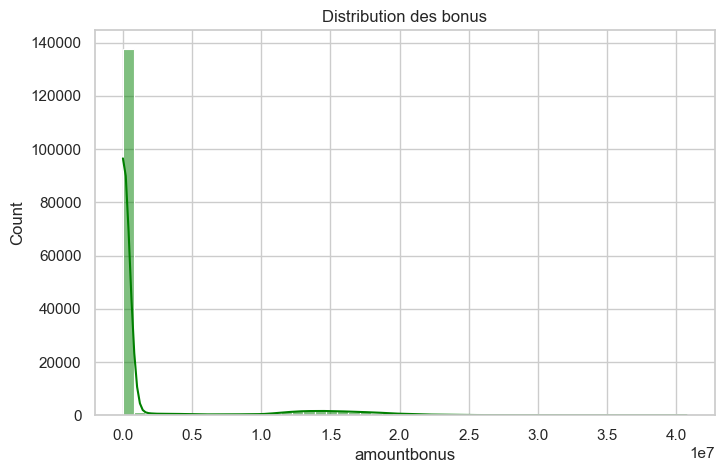

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df_eda['amountbonus'], bins=50, kde=True, color="green")
plt.title("Distribution des bonus")
plt.show()

Remarque : Meme tendance que le chiffre d'affaire, la plus part des bonus sont faibles, seuls quelques cas atteignent des valeurs elevees.

## Repartition par categorie

Ce graphe permettra d'identifier la contribution de chaque usage (Data, SMS, Voix, Forfait, VAS )

C:\Users\Gwladys\AppData\Local\Temp\ipykernel_20656\990409090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="categorie", data=df_eda, order=df_eda["categorie"].value_counts().index, palette="Set2")


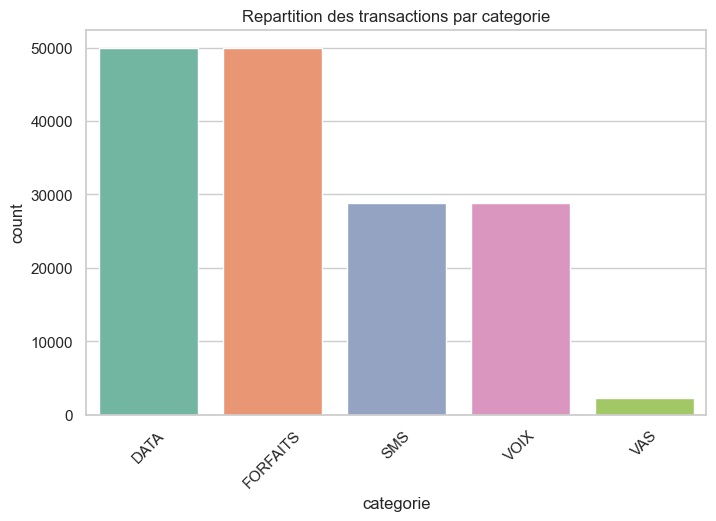

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x="categorie", data=df_eda, order=df_eda["categorie"].value_counts().index, palette="Set2")
plt.title("Repartition des transactions par categorie")
plt.xticks(rotation=45)
plt.show()

Remarque : On observe un desequilibre , certains categorie tels que Data et forfaits dominent largement les transactions.

## Analyse bivariee

## Chiffre d'affaire moyen par categorie

Ce graphique permet de comparer la rentabilite relative des categories et detecter celles qui tirent les revenus vers le haut

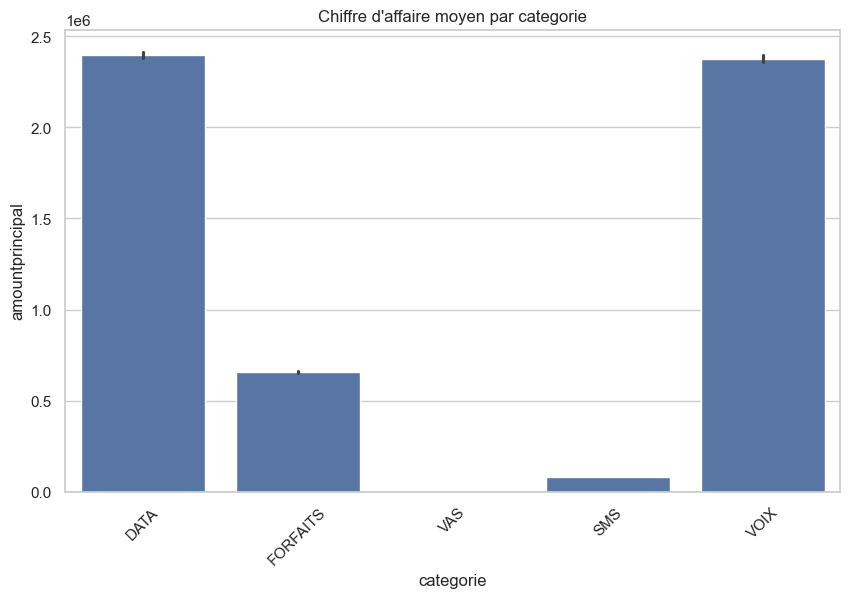

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x="categorie", y="amountprincipal", data=df_eda, estimator="mean")
plt.title("Chiffre d'affaire moyen par categorie")
plt.xticks(rotation=45)
plt.show()

Remarque : Les categories n'ont pas le meme chiffre d'affaire moyen ; Certaines rapportent plusque d'autres.

## Relation bonus VS chiffre d'affaire

Ce graphique permet de tester si les bonus influencent directement le chiffre d'affaire.

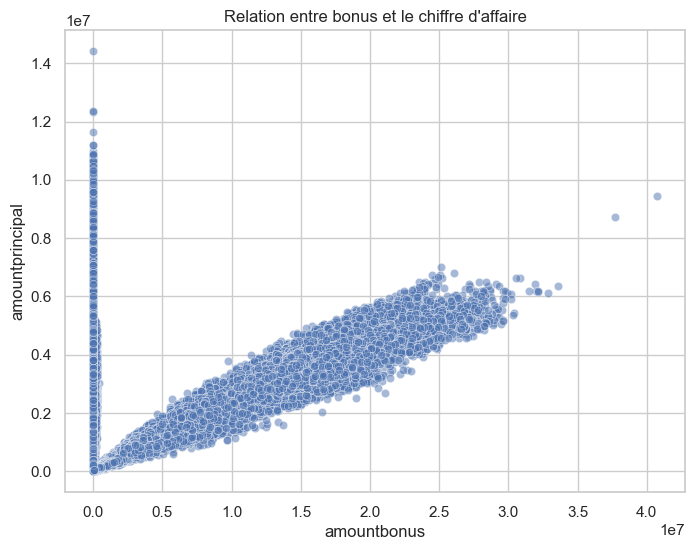

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="amountbonus", y="amountprincipal", data=df_eda, alpha=0.5)
plt.title("Relation entre bonus et le chiffre d'affaire")
plt.show()

Remarque : On observe une correlation positive c'est a dire plus le bonus est elevee , plus le chiffre d'affaire tend a croitre.

## Relation duree VS chiffre d'affaire

Ce graphique permet de verifer si la duree d'utilisation est un facteur explicatif du chiffre d'affaire.

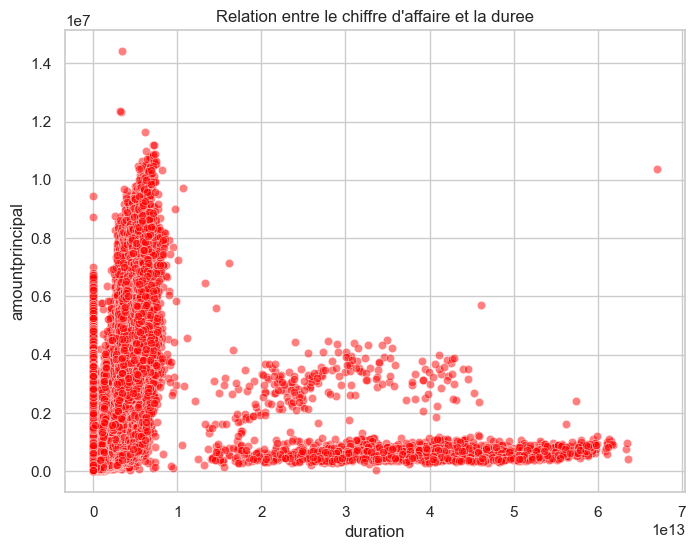

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="duration", y="amountprincipal", data=df_eda, alpha=0.5, color="red")
plt.title("Relation entre le chiffre d'affaire et la duree")
plt.show()

Remarque : le chiffre d'affaire augmente avec la duree, mais reste disperser pour des durees elevees

## Analyse multivariee

## Matrice de correlation

La matrice de correlation permet d'identifier les variables les plus utiles pour un futur modele predictif

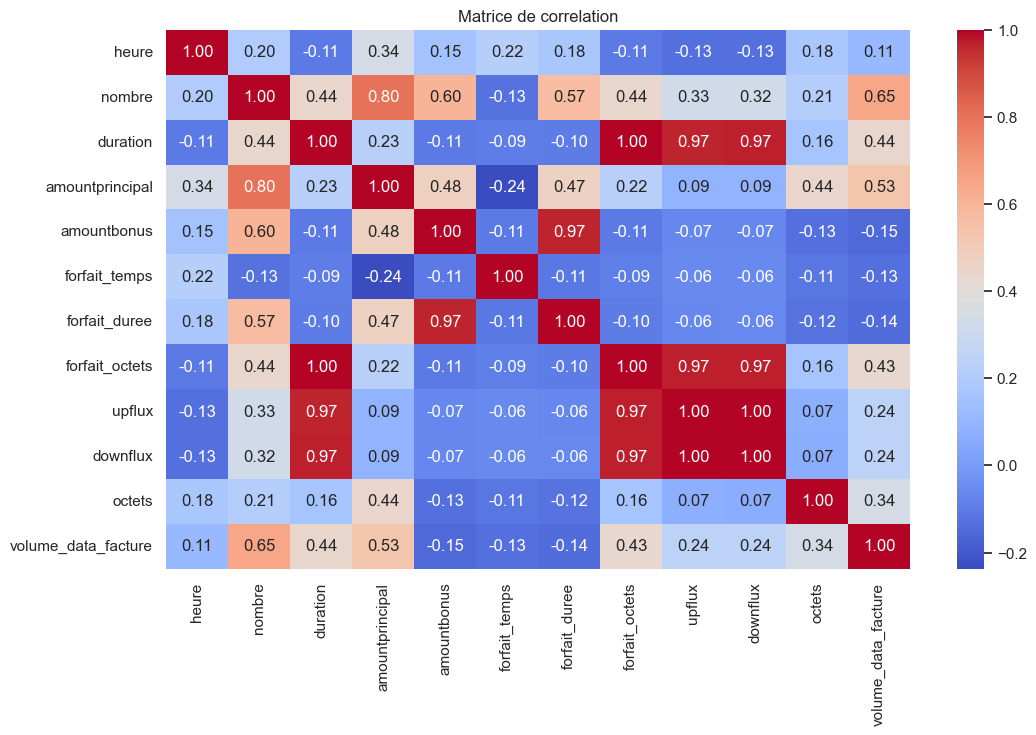

In [35]:
plt.figure(figsize=(12,7))
sns.heatmap(df_eda.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de correlation")
plt.show()

Remarque : Le chiffre d'affaire est surtout correle avec les bonus et la duree, peu avec les octets.

## Pairplot sur un echantillon

Ce pairplot permet de visualiser les interactions globales et confirmer que la categorie joue un role structurant.

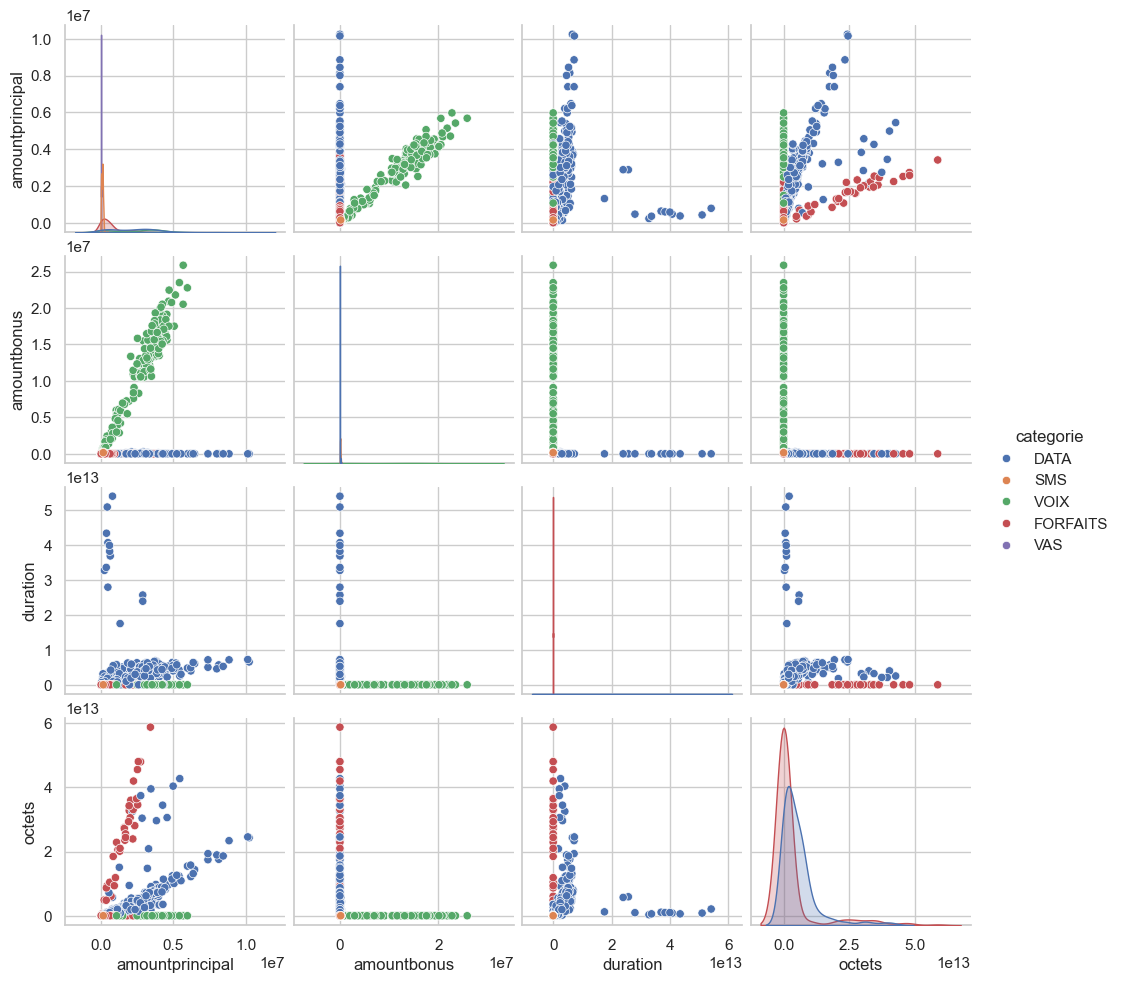

In [36]:
sns.pairplot(df_eda.sample(1000), vars=["amountprincipal","amountbonus","duration","octets"], hue="categorie")
plt.show()

Remarque : Les relations entre variables different selon la categorie, certaines tendances sont visibles.

## Focus sur le chiffre d'affaire par type d'usage

## Agregation du chiffre d'usage par categorie

Ce graphe permet de hierarchiser les sources de revenus et guider les decisions strategiques

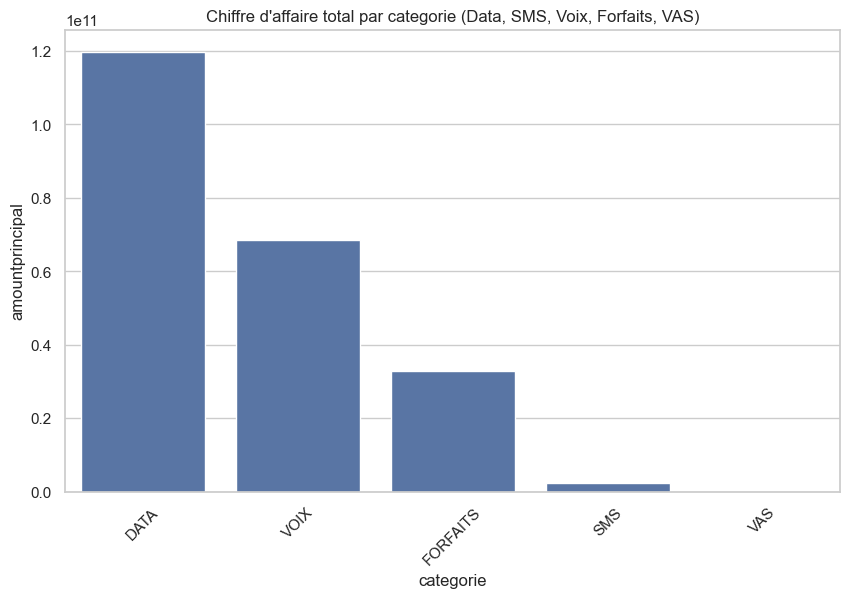

In [37]:
df_eda_ca_cat=df_eda.groupby("categorie")["amountprincipal"].sum().reset_index().sort_values(by="amountprincipal",ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x="categorie",y="amountprincipal",data=df_eda_ca_cat)
plt.title("Chiffre d'affaire total par categorie (Data, SMS, Voix, Forfaits, VAS)")
plt.xticks(rotation=45)
plt.show()

Remarque : Deux categories ( DATA, VOIX ), generent la majorite du chiffre d'affaires

## Evolution du chiffre d'affaire par categorie dans le temps

Ce graphique permet de comprendre la dynamique temporelle du chiffre d'affaire et anticiper les evolutions futures

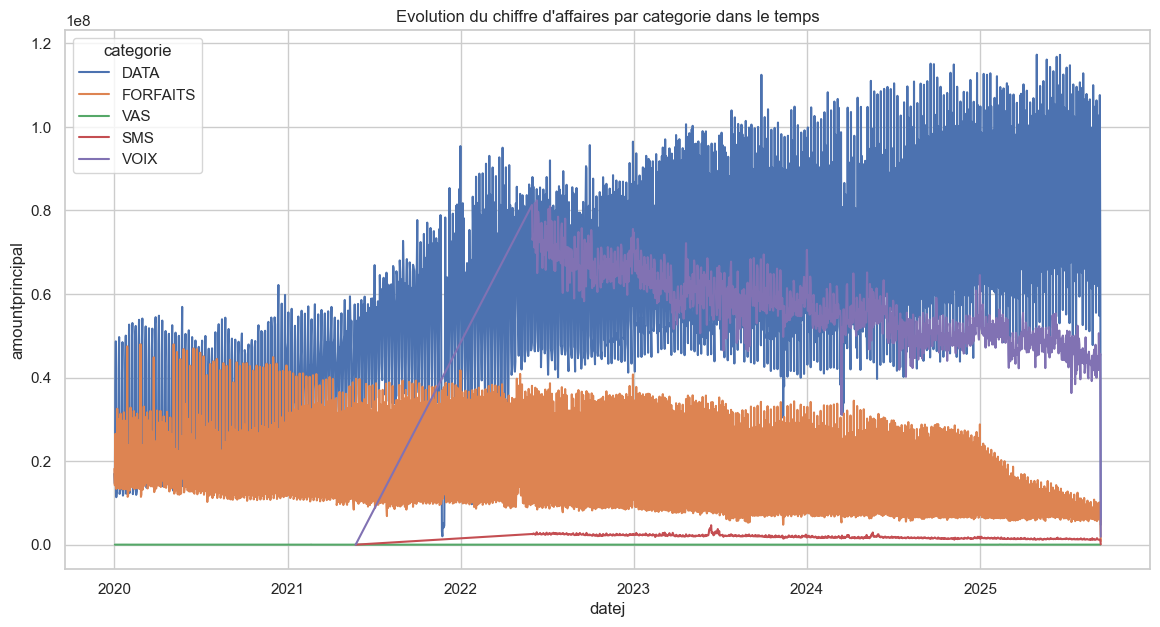

In [38]:
df_eda_time=df_eda.groupby(["datej","categorie"])["amountprincipal"].sum().reset_index()
plt.figure(figsize=(14,7))
sns.lineplot(x="datej", y="amountprincipal", hue="categorie", data=df_eda_time)
plt.title("Evolution du chiffre d'affaires par categorie dans le temps")
plt.show()

Remarque : On observe des tendances saisonnieres , avec des categorie qui croissent plus vite que d'autres.

## Prevision du chiffre d'affaire

In [39]:
!pip install prophet


Prophet est un modèle prêt à l’emploi pour séries temporelles (il modélise tendance + saisonnalités + jours fériés).

In [40]:
from prophet import Prophet

## Préparation des données
Vérifions que ta colonne date est bien en datetime

In [41]:
df_eda["datej"] = pd.to_datetime(df["datej"])

## Agrégation mensuelle du chiffre d’affaires

In [42]:
df_eda_ca = df_eda.groupby(pd.Grouper(key="datej", freq="ME"))["amountprincipal"].sum().reset_index()

In [43]:
print("Aperçu du CA mensuel :")
print(df_eda_ca)

Aperçu du CA mensuel :
        datej  amountprincipal
0  2020-01-31     1.386983e+09
1  2020-02-29     1.385912e+09
2  2020-03-31     1.477662e+09
3  2020-04-30     1.402481e+09
4  2020-05-31     1.546268e+09
..        ...              ...
64 2025-05-31     4.255404e+09
65 2025-06-30     4.189714e+09
66 2025-07-31     4.162432e+09
67 2025-08-31     4.065390e+09
68 2025-09-30     1.437153e+09

[69 rows x 2 columns]


In [44]:
df_eda_ca.sample(20)

,datej,amountprincipal
66,2025-07-31,4.162432e+09
13,2021-02-28,1.665394e+09
39,2023-04-30,4.317054e+09
38,2023-03-31,4.544772e+09
8,2020-09-30,1.499663e+09
21,2021-10-31,2.288176e+09
12,2021-01-31,1.769779e+09
67,2025-08-31,4.065390e+09
64,2025-05-31,4.255404e+09
50,2024-03-31,4.107686e+09


## Visualisation de la série

Cette figure permet d'observer la tendance générale et détecter une éventuelle saisonnalité ou des anomalies.

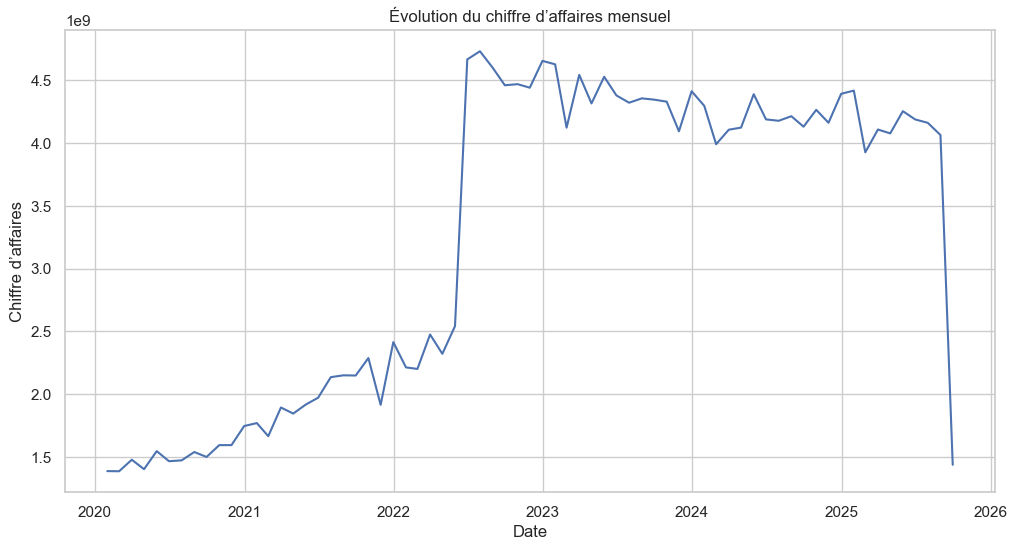

In [45]:
plt.figure(figsize=(12,6))
sns.lineplot(x="datej", y="amountprincipal", data=df_eda_ca)
plt.title("Évolution du chiffre d’affaires mensuel")
plt.xlabel("Date")
plt.ylabel("Chiffre d’affaires")
plt.show()      

Interprétation : Le graphe montre comment le chiffre d’affaires évolue par annees. On peut identifier une croissance, une baisse, des pics saisonniers réguliers ou encore des variations inhabituelles.

## Prévisions avec Prophet
 Préparer les données pour Prophet

In [46]:
df_eda_prophet = df_eda_ca.rename(columns={"datej": "ds", "amountprincipal": "y"})

# ds : date
# y : mois

## Initialiser le modèle

In [47]:
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(df_eda_prophet)

09:02:41 - cmdstanpy - INFO - Chain [1] start processing
09:02:41 - cmdstanpy - INFO - Chain [1] done processing


## Créer un dataframe pour 3 ans supplémentaires

In [48]:
future = model.make_future_dataframe(periods=36, freq="ME") # 36 mois = 3 ans
forecast = model.predict(future)

## Visualisation des prévisions

Ce graphe sert visualiser la projection future du chiffre d’affaires avec une marge d’incertitude.

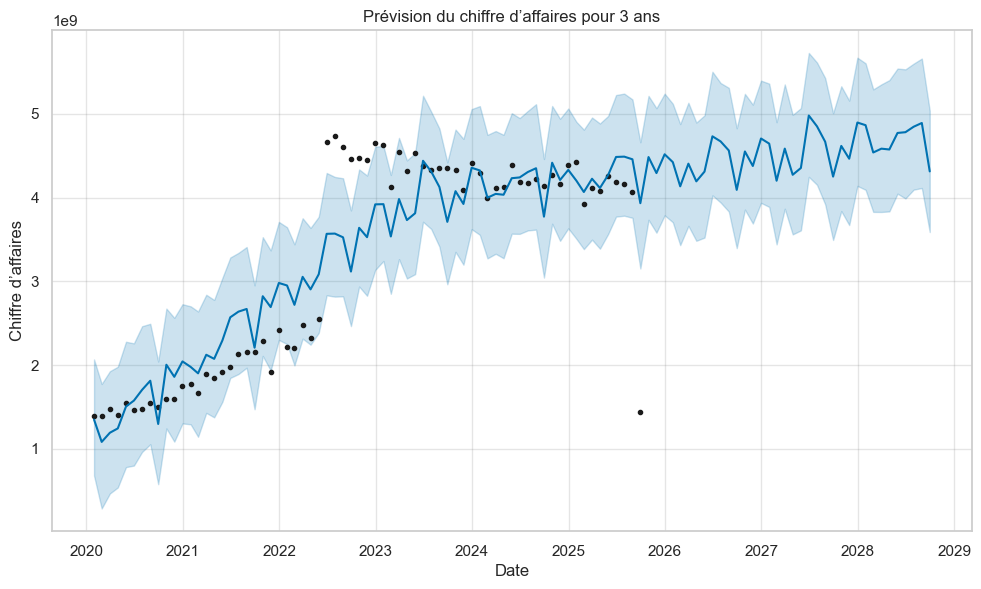

In [49]:
fig1 = model.plot(forecast)
plt.title("Prévision du chiffre d’affaires pour 3 ans")
plt.xlabel("Date")
plt.ylabel("Chiffre d’affaires")
plt.show()

Interpretation : La courbe yhat donne l’évolution prévue, entourée d’un intervalle (yhat_lower et yhat_upper). Plus la bande est large, plus la prévision est incertaine. Cela aide à anticiper l’activité sur 3 ans.

## Décomposition : tendance + saisonnalité

Ce graphe permet décomposer la série et comprendre ce qui influence le chiffre d’affaires

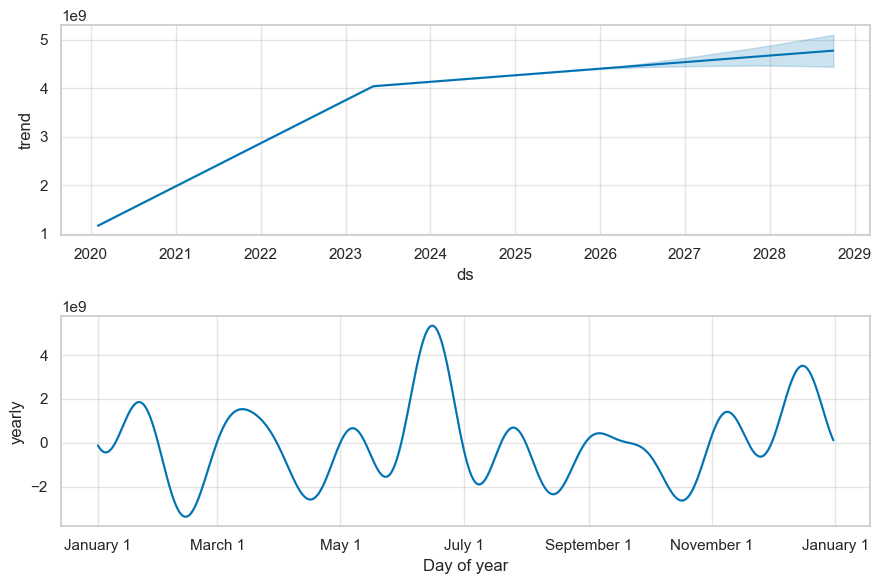

In [50]:
fig2 = model.plot_components(forecast)
plt.show()

Interprétation : Le graphe de tendance montre la direction à long terme (hausse, baisse, stagnation). Le graphe de saisonnalité indique les périodes de l’année où le Chiffre d'affaire a tendance à monter ou descendre.

## Aperçu des résultats

Cette ligne affiche les 12 dernières lignes du DataFrame forecast — normalement ce seront des mois dans la partie finale du futur (les 12 derniers mois du horizon de 36 mois).

In [51]:
print("Prévisions prochaines périod cvces :")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12))

Prévisions prochaines périod cvces :
            ds          yhat    yhat_lower    yhat_upper
93  2027-10-31  4.616287e+09  3.837886e+09  5.329340e+09
94  2027-11-30  4.463549e+09  3.670350e+09  5.157802e+09
95  2027-12-31  4.895948e+09  4.138613e+09  5.671057e+09
96  2028-01-31  4.864263e+09  4.092030e+09  5.603948e+09
97  2028-02-29  4.538047e+09  3.828078e+09  5.292034e+09
98  2028-03-31  4.583664e+09  3.826968e+09  5.352224e+09
99  2028-04-30  4.573794e+09  3.833721e+09  5.402793e+09
100 2028-05-31  4.771347e+09  4.046014e+09  5.541068e+09
101 2028-06-30  4.780557e+09  3.988623e+09  5.531656e+09
102 2028-07-31  4.845580e+09  4.093345e+09  5.599678e+09
103 2028-08-31  4.890500e+09  4.113692e+09  5.660366e+09
104 2028-09-30  4.312126e+09  3.586976e+09  5.038057e+09


yhat = prévision ponctuelle (moyenne), yhat_lower / yhat_upper = intervalle d’incertitude (par défaut interval_width=0.80 soit 80 %).


Interprétation : On observe l’augmentation/diminution de yhat sur ces 12 mois, et la largeur de l’intervalle — si l’intervalle est large, la prévision est incertaine.

## Interface Streamlit

In [52]:
!pip install streamlit_jupyter

In [53]:
from streamlit_jupyter import StreamlitPatcher, tqdm
import streamlit as st

# Activer le patch pour exécuter dans Jupyter
StreamlitPatcher().jupyter()

st.title("Streamlit dans Jupyter 😍")
st.write("Ici, Streamlit s'affiche directement dans le notebook.")


# Streamlit dans Jupyter 😍

Ici, Streamlit s'affiche directement dans le notebook.

In [54]:
from prophet import Prophet
print("✅ Prophet est bien installé")

✅ Prophet est bien installé


In [55]:
%%writefile projet.py
import streamlit as st
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Telecel_revenue.xlsx")
df["datej"] = pd.to_datetime(df["datej"])
df_ca = df.groupby(pd.Grouper(key="datej", freq="M"))["amountprincipal"].sum().reset_index()

st.title("Prévision du Chiffre d’Affaires - Telecel")

st.subheader("Aperçu du CA mensuel")
st.dataframe(df_ca.head())

df_prophet = df_ca.rename(columns={"datej": "ds", "amountprincipal": "y"})
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(df_prophet)
future = model.make_future_dataframe(periods=36, freq="M")
forecast = model.predict(future)

annee = st.number_input("Année", min_value=2022, max_value=2030, value=2025)
mois = st.number_input("Mois", min_value=1, max_value=12, value=1)

if st.button("Prédire le CA"):
    date_pred = pd.to_datetime(f"{annee}-{mois}-01") + pd.offsets.MonthEnd(0)
    resultat = forecast[forecast["ds"] == date_pred]
    if not resultat.empty:
        yhat = resultat["yhat"].values[0]
        st.success(f"Prévision pour {date_pred.strftime('%B %Y')}: {yhat:,.2f}")
    else:
        st.warning("Date hors de l’horizon de prévision")


Overwriting projet.py


In [ ]:
!streamlit run projet.py  